In [1]:
import numpy as np
import pandas as pd
import sqlite3
import geopandas as gpd
import os
import matplotlib.pyplot as plt
from scipy.stats import gamma, norm

In [2]:
# filepaths
grupo11_database = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\Grupo_11\BD\BD_Grupo_11.sqlite"
CMIP6_spitest = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\Grupo_11\BD\CMIP685_SPIData.csv"
PISCO_spitest = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\Grupo_11\BD\PISCO_SPIData.csv"

In [3]:
cmip6_spi = pd.read_csv(CMIP6_spitest)
pisco_spi = pd.read_csv(PISCO_spitest)

In [4]:
# format date columns
pisco_spi['measured_date'] = pd.to_datetime(pisco_spi['measured_date'],errors='coerce')
cmip6_spi['measured_date'] = pd.to_datetime(cmip6_spi['measured_date'],errors='coerce')

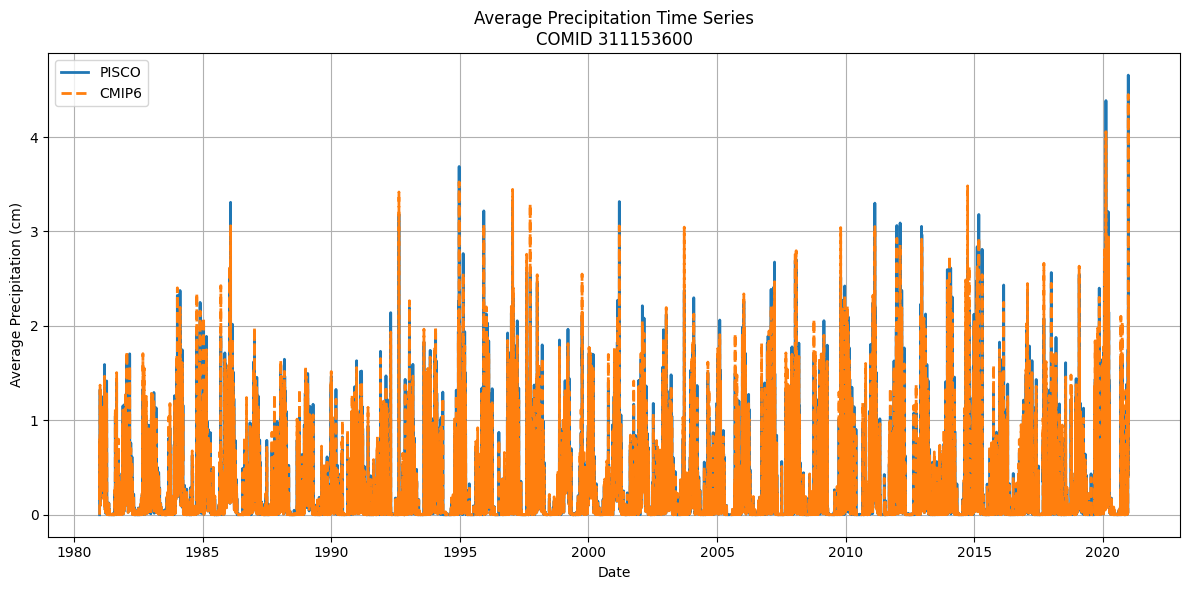

In [5]:
# test plot for output from waterALLOC

test_comid = '311153600'

# filter data for the test COMID
pisco_comid = pisco_spi[pisco_spi['comid'].astype(str) == test_comid].sort_values('measured_date')
cmip6_comid = cmip6_spi[cmip6_spi['comid'].astype(str) == test_comid].sort_values('measured_date')

# create the plot
plt.figure(figsize=(12, 6))

plt.plot(
    pisco_comid['measured_date'],
    pisco_comid['avg_precip_cm'],
    label='PISCO',
    linewidth=2
)

plt.plot(
    cmip6_comid['measured_date'],
    cmip6_comid['avg_precip_cm'],
    label='CMIP6',
    linewidth=2,
    linestyle='--'
)

plt.xlabel('Date')
plt.ylabel('Average Precipitation (cm)')
plt.title(f'Average Precipitation Time Series\nCOMID {test_comid}')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
scenarios = {
    1: {"met_source_id": 2},  # Baseline
    2: {"met_source_id": 5},  # Future
}

In [7]:
# get daily precipitation data from met table
dfs = []   # list to store each scenario's data

conn = sqlite3.connect(grupo11_database)

for ScnID, scn_info in scenarios.items():
    
    query = f"""
    SELECT
        comid,
        avg_precip_cm,
        measured_date
    FROM catchment_met_observations
    WHERE met_source_id = {scn_info['met_source_id']};
    """

    met = pd.read_sql_query(query, conn)

    met['measured_date'] = pd.to_datetime(met['measured_date'], format='%Y-%m-%d %H:%M:%S %z UTC', errors='coerce' )
    
    # drop rows with bad dates
    met = met.dropna(subset=['measured_date'])
    
    # add scenario ID column
    met['ScnID'] = ScnID

    # append to list
    dfs.append(met)

conn.close()

# combine all scenarios into a single tidy dataframe
df = pd.concat(dfs, ignore_index=True)

# reorder columns if you want
df = df[['ScnID', 'comid', 'measured_date', 'avg_precip_cm']]

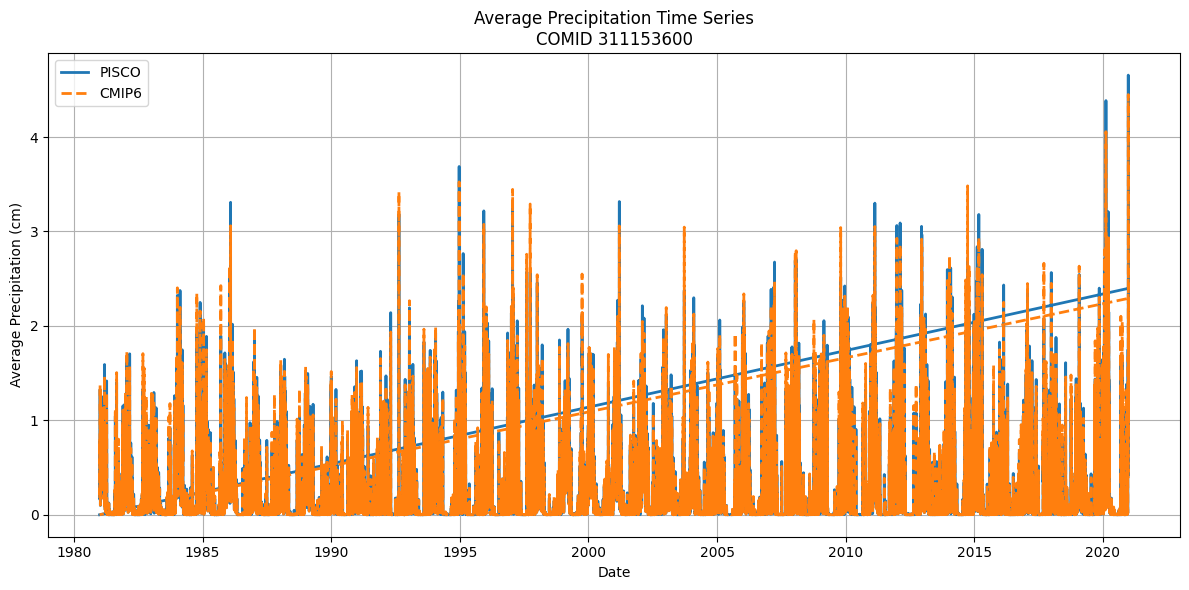

In [ ]:
# test plot of precip time series from the met tables

test_comid = '311153600'

# filter data for the test COMID
df_filtered_pisco = df[
    (df['ScnID'] == 1) &
    (df['comid'].astype(str) == test_comid)
]

df_filtered_cmip6 = df[
    (df['ScnID'] == 2) &
    (df['comid'].astype(str) == test_comid)
]

# create the plot
plt.figure(figsize=(12, 6))

plt.plot(
    df_filtered_pisco['measured_date'],
    df_filtered_pisco['avg_precip_cm'],
    label='PISCO',
    linewidth=2
)

plt.plot(
    df_filtered_cmip6['measured_date'],
    df_filtered_cmip6['avg_precip_cm'],
    label='CMIP6',
    linewidth=2,
    linestyle='--'
)

plt.xlabel('Date')
plt.ylabel('Average Precipitation (cm)')
plt.title(f'Average Precipitation Time Series\nCOMID {test_comid}')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [19]:
# function to calculate spi for a given monthly time series of precipitation and time scale for SPI (where the time scale is the number of months)

def calculate_spi(precip_series,scale):
    # Aggregate precipitation over the specified scale (rolling sum)
    rolling_precip = precip_series.rolling(window=scale, min_periods=scale).sum()

    #remove NaNs and replace 0s with a very small positive value
    rolling_precip_clean = rolling_precip.dropna() + 1e-6

    # Fit the rolling precipitation to a gamma distribution
    shape, loc, scale = gamma.fit(rolling_precip_clean.dropna(), floc=0)  # Force location to zero
    
    # Calculate the cumulative probability for the observed values
    cdf = gamma.cdf(rolling_precip, shape, loc=loc, scale=scale)
    
    cdf = np.clip(cdf, 1e-6, 1 - 1e-6)
    # Convert cumulative probability to SPI (standard normal distribution)
    spi = norm.ppf(cdf)  # Inverse of the normal CDF
    
    return pd.Series(spi, index=precip_series.index)

In [20]:
# convert precip from cm to mm
df['avg_precip_mm'] = df['avg_precip_cm'] * 10

# convert daily precip to monthly
df['year_month'] = df['measured_date'].dt.to_period('M')  # e.g., 1981-01

monthly_precip = (df.groupby(['ScnID', 'comid', 'year_month'])['avg_precip_mm'].sum().reset_index())

# convert year_month back to datetime for plotting
monthly_precip['month_start'] = monthly_precip['year_month'].dt.to_timestamp()

C:\Users\sbakar\AppData\Local\Temp\ipykernel_127796\273555877.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['measured_date'].dt.to_period('M')  # e.g., 1981-01


In [27]:
#function to calculate 1-month spi for each COMID by scenario
def calculate_spi_for_group(group, scale):
    group = group.sort_values('month_start')
    group['SPI_1'] = calculate_spi(group['avg_precip_mm'], scale)
    return group

In [30]:
spi_1month = (monthly_precip.groupby(['ScnID', 'comid']).apply(calculate_spi_for_group, scale=1).reset_index(drop=True))

C:\Users\sbakar\AppData\Local\Temp\ipykernel_127796\1209409523.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  spi_1month = (monthly_precip.groupby(['ScnID', 'comid']).apply(calculate_spi_for_group, scale=1).reset_index(drop=True))


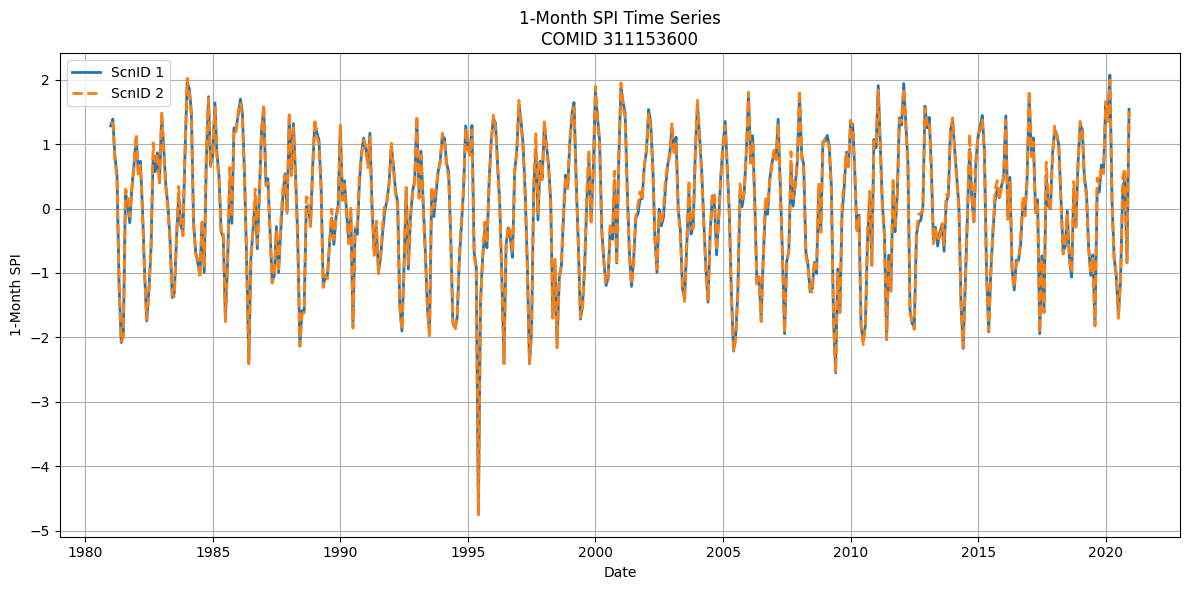

In [31]:
# test COMID
test_comid = '311153600'

# filter SPI data for the test COMID and ScnIDs 1 and 2
spi_comid = spi_1month[
    (spi_1month['comid'].astype(str) == test_comid) &
    (spi_1month['ScnID'].isin([1, 2]))
].sort_values('month_start')

# create the plot
plt.figure(figsize=(12, 6))

# loop over the scenarios for plotting
for scn_id, group in spi_comid.groupby('ScnID'):
    plt.plot(
        group['month_start'],
        group['SPI_1'],
        label=f'ScnID {scn_id}',
        linewidth=2,
        linestyle='-' if scn_id == 1 else '--'
    )

plt.xlabel('Date')
plt.ylabel('1-Month SPI')
plt.title(f'1-Month SPI Time Series\nCOMID {test_comid}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()